In [16]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
from moco.loader import *
from moco.stain_augmentation import *
import matplotlib.pyplot as plt
import moco

In [3]:
dataset = TileDataset("/home/maelmontillet/primacode/images/train")

In [4]:
len(dataset)

6

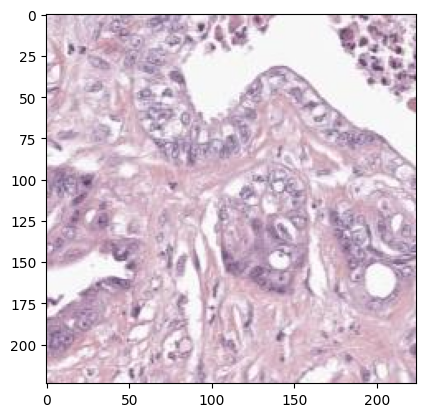

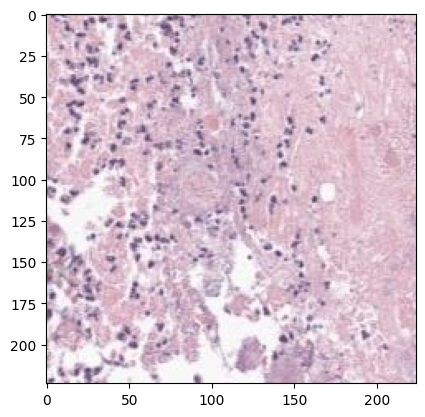

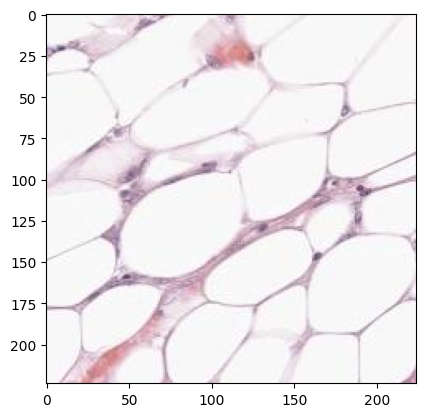

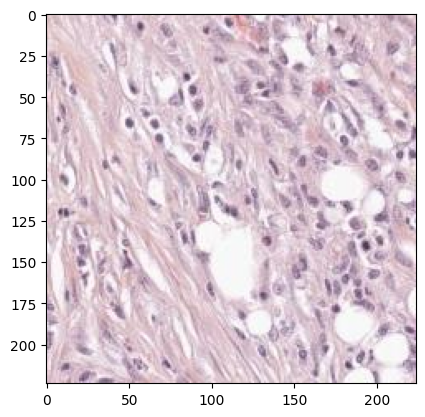

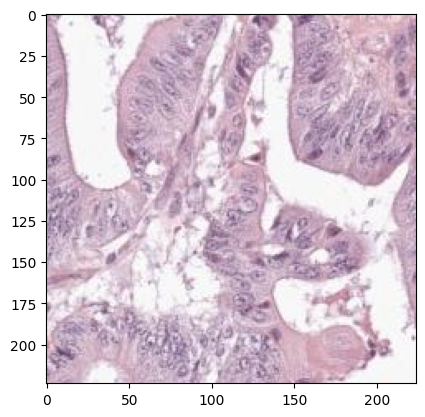

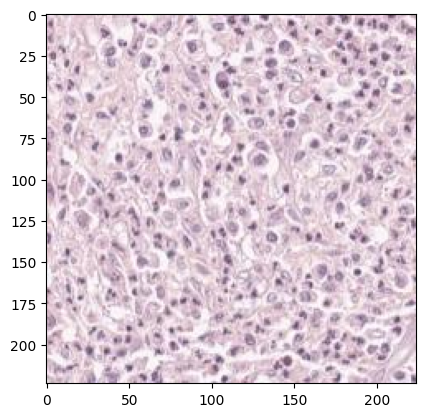

In [5]:
for img in dataset:
    plt.imshow(img)
    plt.show()

In [8]:
from torch.utils.data import DataLoader
import torchvision.transforms as transforms

normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])

augmentation1 = [
    transforms.ToPILImage(),
    transforms.RandomResizedCrop(224, scale=(0.2, 1.)),
    transforms.RandomApply([
        transforms.ColorJitter(0.4, 0.4, 0.2, 0.1)  # not strengthened
    ], p=0.8),
    transforms.RandomGrayscale(p=0.2),
    transforms.RandomApply([moco.loader.GaussianBlur([.1, 2.])], p=1.0),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    normalize
]

augmentation2 = [
    transforms.ToPILImage(),
    transforms.RandomResizedCrop(224, scale=(0.2, 1.)),
    transforms.RandomApply([
        transforms.ColorJitter(0.4, 0.4, 0.2, 0.1)  # not strengthened
    ], p=0.8),
    transforms.RandomGrayscale(p=0.2),
    transforms.RandomApply([moco.loader.GaussianBlur([.1, 2.])], p=0.1),
    transforms.RandomApply([moco.loader.Solarize()], p=0.2),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    normalize
]

collate_fn = MyCollateFunction(transforms.Compose(augmentation1), 
                                                          transforms.Compose(augmentation2), 
                                                          moco.stain_augmentation.all_free_version())

# Num worker

train_loader = DataLoader(dataset, batch_size=2, shuffle=True, 
                        collate_fn = collate_fn, 
                        pin_memory=True,  drop_last=True,
                        #num_workers=1,
                       )

In [9]:
inv_normalize = transforms.Normalize(
    mean=[-m/s for m, s in zip([0.485, 0.456, 0.406],
                               [0.229, 0.224, 0.225])],
    std=[1/s for s in [0.229, 0.224, 0.225]]
)
for i, (images, _) in enumerate(train_loader):
    for i in range(len(images[0])):
        images[0] = images[0].cuda()
        images[1] = images[1].cuda()
        print(i)
        plt.imshow(inv_normalize(images[0][i].cpu()).permute(1, 2, 0))
        plt.show()
        plt.imshow(inv_normalize(images[1][i].cpu()).permute(1, 2, 0))
        plt.show()

/home/maelmontillet/primacode/primacode_env/lib/python3.8/site-packages/torchvision/transforms/functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


AttributeError: 'Tensor' object has no attribute 'filter'

In [15]:
import os

os.path.join("test/test1", "*.tar")

'test/test1/*.tar'